In [15]:
import re
from collections import defaultdict
from pathlib import Path

import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq
import tangram as tg
from anndata import AnnData
from matplotlib.colors import LogNorm, Normalize
from matplotlib.legend_handler import HandlerTuple
from tqdm import tqdm

In [31]:
cell_types = ["Tumor", "Vascular", "Immune", "Stroma"]
n_obs = 1000

# Define niche probabilities for each cell type
niche_probabilities = {
    "Tumor": [0.6, 0.1, 0.3],   # Tumor has a 60% chance of being in niche 1, etc.
    "Vascular": [0.2, 0.5, 0.3], # Vascular is more likely to be in niche 2
    "Immune": [0.3, 0.2, 0.5],   # Immune is most often in niche 3
    "Stroma": [0.4, 0.1, 0.5]    # Stroma is similar to Tumor in distribution
}

# Randomly assign cell types
cell_type_annotations = np.random.choice(cell_types, size=n_obs)

# Assign niche annotations based on the corresponding probabilities
niche_annotations = np.array([
    np.random.choice([1, 2, 3], p=niche_probabilities[cell_type]) for cell_type in cell_type_annotations
])

df = pd.DataFrame({
    "cell_type": cell_type_annotations,
    "niche": niche_annotations
})

adata = ad.AnnData(obs=df)

In [19]:
adata.obs

,cell_type,niche
0,Tumor,1
1,Vascular,1
2,Vascular,1
3,Stroma,3
4,Vascular,3
...,...,...
995,Immune,3
996,Tumor,1
997,Immune,3
998,Immune,3


In [8]:
def _proportion(obs, id_key, val_key, normalize=True):
    df = pd.pivot(obs[[id_key, val_key]].value_counts().reset_index(), index=id_key, columns=val_key)
    df[df.isna()] = 0
    df.columns = df.columns.droplevel(0)
    if normalize:
        return df.div(df.sum(axis=1), axis=0)
    else:
        return df


def _observed_permuted(annotations, group_key, label_key):
    annotations[group_key] = annotations[group_key].sample(frac=1).reset_index(drop=True).values
    return _proportion(annotations, id_key=label_key, val_key=group_key).reindex().T


def _enrichment(observed, expected, log=True):
    enrichment = observed.div(expected, axis="index", level=0)

    if log:
        with np.errstate(divide="ignore"):
            enrichment = np.log2(enrichment)
    enrichment = enrichment.fillna(enrichment.min())
    return enrichment


def _empirical_pvalues(observed, expected):
    pvalues = np.zeros(observed.shape)
    pvalues[observed.values > 0] = (
        1 - np.sum(expected[:, observed.values > 0] < observed.values[observed.values > 0], axis=0) / expected.shape[0]
    )
    pvalues[observed.values < 0] = (
        1 - np.sum(expected[:, observed.values < 0] > observed.values[observed.values < 0], axis=0) / expected.shape[0]
    )
    return pd.DataFrame(pvalues, columns=observed.columns, index=observed.index)

def enrichment(
    adata: AnnData,
    group_key: str,
    label_key: str,
    pvalues: bool = False,
    n_perms: int = 1000,
    log: bool = True,
    observed_expected: bool = False,
    copy: bool = False,
) -> pd.DataFrame | tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame] | None:
    """
    Compute the enrichment of `label_key` in `group_key`.

    Parameters
    ----------
    %(adata)s
    group_key
        Key in :attr:`anndata.AnnData.obs` where groups are stored.
    label_key
        Key in :attr:`anndata.AnnData.obs` where labels are stored.
    pvalues
        If `True`, compute empirical p-values by permutation. It will result in a slower computation.
    n_perms
        Number of permutations to compute empirical p-values.
    log
        If `True` use log2 fold change, otherwise use fold change.
    observed_expected
        If `True`, return also the observed and expected proportions.
    %(copy)s

    Returns
    -------
    If ``copy = True``, returns a :class:`dict` with the following keys:
        - ``'enrichment'`` - the enrichment values.
        - ``'pvalue'`` - the enrichment pvalues (if `pvalues is True`).
        - ``'observed'`` - the observed proportions (if `observed_expected is True`).
        - ``'expected'`` - the expected proportions (if `observed_expected is True`).

    Otherwise, modifies the ``adata`` with the following keys:
        - :attr:`anndata.AnnData.uns` ``['{group_key}_{label_key}_nhood_enrichment']`` - the above mentioned dict.
        - :attr:`anndata.AnnData.uns` ``['{group_key}_{label_key}_nhood_enrichment']['params']`` - the parameters used.
    """
    observed = _proportion(adata.obs, id_key=label_key, val_key=group_key).reindex().T
    observed[observed.isna()] = 0
    if not pvalues:
        expected = adata.obs[group_key].value_counts() / adata.shape[0]
        # Repeat over the number of labels
        expected = pd.concat([expected] * len(observed.columns), axis=1, keys=observed.columns)
    else:
        annotations = adata.obs.copy()

        expected = [_observed_permuted(annotations, group_key, label_key) for _ in tqdm(range(n_perms))]
        expected = np.stack(expected, axis=0)

        empirical_pvalues = _empirical_pvalues(observed, expected)

        expected = np.mean(expected, axis=0)
        expected = pd.DataFrame(expected, columns=observed.columns, index=observed.index)

    enrichment = _enrichment(observed, expected, log=log)

    result = {"enrichment": enrichment}

    if observed_expected:
        result["observed"] = observed
        result["expected"] = expected

    if pvalues:
        result["pvalue"] = empirical_pvalues

    if copy:
        return result
    else:
        adata.uns[f"{group_key}_{label_key}_enrichment"] = result
        adata.uns[f"{group_key}_{label_key}_enrichment"]["params"] = {"log": log}

In [32]:
enrichment(adata, group_key="niche", label_key="cell_type", pvalues=True)

100%|██████████| 1000/1000 [00:01<00:00, 629.54it/s]


In [33]:
adata.uns['niche_cell_type_enrichment']

{'enrichment': cell_type    Immune    Stroma     Tumor  Vascular
 niche                                            
 1         -0.137553 -0.125284  0.691197 -0.808429
 2         -0.235627 -1.020007 -1.306527  1.153979
 3          0.223328  0.438377 -0.426891 -0.425459,
 'pvalue': cell_type  Immune  Stroma  Tumor  Vascular
 niche                                     
 1           0.916   0.905    0.0       1.0
 2           0.924   1.000    1.0       0.0
 3           0.013   0.000    1.0       1.0,
 'params': {'log': True}}

In [34]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from anndata import AnnData
from matplotlib.colors import LogNorm, Normalize
from matplotlib.legend_handler import HandlerTuple
from scipy.cluster import hierarchy
from squidpy._docs import d
from squidpy.gr._utils import _assert_categorical_obs
from squidpy.pl._color_utils import Palette_t, _get_palette, _maybe_set_colors

from matplotlib.pyplot import get_cmap


empty_handle = matplotlib.patches.Rectangle((0, 0), 1, 1, fill=False, edgecolor="none", visible=False)


@d.dedent
def proportion(
    adata: AnnData,
    group_key: str,
    label_key: str,
    groups: list | None = None,
    labels: list | None = None,
    rotation_xlabel: int = 45,
    ncols: int = 1,
    normalize: bool = True,
    palette: Palette_t = None,
    figsize: tuple[float, float] | None = None,
    dpi: int | None = None,
    save: str | Path | None = None,
    **kwargs,
) -> None:
    """
    Plot the proportion of `y_key` in `x_key`.

    Parameters
    ----------
    %(adata)s
    group_key
        Key in :attr:`anndata.AnnData.obs` where groups are stored.
    label_key
        Key in :attr:`anndata.AnnData.obs` where labels are stored.
    groups
        List of groups to plot.
    labels
        List of labels to plot.
    rotation_xlabel
        Rotation in degrees of the ticks of the x axis.
    ncols
        Number of columns for the legend.
    normalize
        If `True` use relative frequencies, outherwise use counts.
    palette
        Categorical colormap for the clusters.
        If ``None``, use :attr:`anndata.AnnData.uns` ``['{{cluster_key}}_colors']``, if available.
    %(plotting)s
    kwargs
        Keyword arguments for :func:`pandas.DataFrame.plot.bar`.
    Returns
    -------
    %(plotting_returns)s
    """
    _assert_categorical_obs(adata, key=group_key)
    _assert_categorical_obs(adata, key=label_key)
    _maybe_set_colors(source=adata, target=adata, key=label_key, palette=palette)

    clusters = adata.obs[label_key].cat.categories
    palette = _get_palette(adata, cluster_key=label_key, categories=clusters)

    df = _proportion(obs=adata.obs, id_key=group_key, val_key=label_key, normalize=normalize)
    df = df[df.columns[::-1]]

    if groups is not None:
        df = df.loc[groups, :]

    if labels is not None:
        df = df.loc[:, labels]

    plt.figure(dpi=dpi)
    ax = df.plot.bar(stacked=True, figsize=figsize, color=palette, rot=rotation_xlabel, ax=plt.gca(), **kwargs)
    ax.grid(False)

    handles, labels = ax.get_legend_handles_labels()
    lgd = ax.legend(handles[::-1], labels[::-1], loc="center left", ncol=ncols, bbox_to_anchor=(1.0, 0.5))

    if save:
        plt.savefig(save, bbox_extra_artists=(lgd, lgd), bbox_inches="tight")


def _select_labels(fold_change, pvalues, labels, groups):
    col_name = fold_change.columns.name
    idx_name = fold_change.index.name

    if labels is not None:
        fold_change = fold_change.loc[labels]

        # The indexing removes the name of the index, so we need to set it back
        fold_change.index.name = idx_name

        if pvalues is not None:
            pvalues = pvalues.loc[labels]

            # The indexing removes the name of the index, so we need to set it back
            pvalues.index.name = idx_name

    if groups is not None:
        fold_change = fold_change.loc[:, groups]

        # The indexing removes the name of the columns, so we need to set it back
        fold_change.columns.name = col_name

        if pvalues is not None:
            pvalues = pvalues.loc[:, groups]

            # The indexing removes the name of the columns, so we need to set it back
            pvalues.columns.name = col_name

    return fold_change, pvalues


# Calculate the dendrogram for rows and columns clustering
def _reorder_labels(fold_change, pvalues, group_cluster, label_cluster):
    if label_cluster:
        order_rows = hierarchy.leaves_list(hierarchy.linkage(fold_change, method="complete"))
        fold_change = fold_change.iloc[order_rows]

        if pvalues is not None:
            pvalues = pvalues.iloc[order_rows]

    if group_cluster:
        order_cols = hierarchy.leaves_list(hierarchy.linkage(fold_change.T, method="complete"))
        fold_change = fold_change.iloc[:, order_cols]

        if pvalues is not None:
            pvalues = pvalues.iloc[:, order_cols]
    return fold_change, pvalues


def _significance_colors(color, pvalues, significance):
    color[pvalues <= significance] = 0.0
    color[pvalues > significance] = 0.8
    return color


def _pvalue_colorbar(ax, cmap_enriched, cmap_depleted, norm):
    from matplotlib.colorbar import ColorbarBase
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(ax)

    # Append axes to the right of ax, with 5% width of ax
    cax1 = divider.append_axes("right", size="2%", pad=0.05)

    cbar1 = ColorbarBase(cax1, cmap=cmap_enriched, norm=norm, orientation="vertical")

    cbar1.ax.invert_yaxis()
    cbar1.ax.tick_params(labelsize=10)
    cbar1.set_ticks([], minor=True)
    cbar1.ax.set_title("p-value", fontdict={"fontsize": 10})

    if cmap_depleted is not None:
        cax2 = divider.append_axes("right", size="2%", pad=0.10)

        # Place colorbars next to each other and share ticks
        cbar2 = ColorbarBase(cax2, cmap=cmap_depleted, norm=norm, orientation="vertical")
        cbar2.ax.invert_yaxis()
        cbar2.ax.tick_params(labelsize=10)
        cbar2.set_ticks([], minor=True)

        cbar1.set_ticks([])


def _enrichment_legend(
    scatters, fold_change_melt, dot_scale, size_max, enriched_only, significant_only, significance, size_threshold
):
    handles_list = []
    labels_list = []

    if enriched_only is False:
        handles_list.extend(
            [scatter.legend_elements(prop="colors", num=None)[0][0] for scatter in scatters] + [empty_handle]
        )
        labels_list.extend(["Enriched", "Depleted", ""])

    if significance is not None:
        handles_list.append(tuple([scatter.legend_elements(prop="colors", num=None)[0][0] for scatter in scatters]))
        labels_list.append(f"p-value < {significance}")

        if significant_only is False:
            handles_list.append(tuple([scatter.legend_elements(prop="colors", num=None)[0][1] for scatter in scatters]))
            labels_list.append(f"p-value >= {significance}")

        handles_list.append(empty_handle)
        labels_list.append("")

    handles, labels = scatters[0].legend_elements(prop="sizes", num=5, func=lambda x: x / 100 / dot_scale * size_max)

    if size_threshold is not None:
        # Show the threshold as a label only if the threshold is lower than the maximum fold change
        if enriched_only is True and fold_change_melt[fold_change_melt["value"] >= 0]["value"].max() > size_threshold:
            labels[-1] = f">{size_threshold:.1f}"
        elif fold_change_melt["value"].max() > size_threshold:
            labels[-1] = f">{size_threshold:.1f}"

    handles_list.extend([empty_handle] + handles)
    labels_list.extend(["log2 FC"] + labels)

    return handles_list, labels_list


@d.dedent
def plot_enrichment(
    adata: AnnData,
    group_key: str,
    label_key: str,
    dot_scale: float = 3,
    group_cluster: bool = True,
    label_cluster: bool = False,
    groups: list | None = None,
    labels: list | None = None,
    show_pvalues: bool = False,
    significance: float | None = None,
    enriched_only: bool = True,
    significant_only: bool = False,
    size_threshold: float | None = None,
    palette: str | matplotlib.colors.ListedColormap | None = None,
    fontsize: str | int = "small",
    figsize: tuple[float, float] | None = (7, 5),
    save: str | Path | None = None,
    **kwargs,
):
    """
    Plot a dotplot of the enrichment of `label_key` in `group_key`.

    Parameters
    ----------
    %(adata)s
    group_key
        Key in :attr:`anndata.AnnData.obs` where groups are stored.
    label_key
        Key in :attr:`anndata.AnnData.obs` where labels are stored.
    dot_scale
        Scale of the dots.
    group_cluster
        If `True`, display groups ordered according to hierarchical clustering.
    label_cluster
        If `True`, display labels ordered according to hierarchical clustering.
    groups
        The groups for which to show the enrichment.
    labels
        The labels for which to show the enrichment.
    show_pvalues
        If `True`, show p-values as colors.
    significance
        If not `None`, show fold changes with a p-value above this threshold in a lighter color.
    enriched_only
        If `True`, display only enriched values and hide depleted values.
    significant_only
        If `True`, display only significant values and hide non-significant values.
    size_threshold
        Threshold for the size of the dots. Enrichment or depletions with absolute value above this threshold will have all the same size.
    palette
        Colormap for the enrichment values. It must be a diverging colormap.
    %(plotting)s
    kwargs
        Keyword arguments for :func:`matplotlib.pyplot.scatter`.
    """
    if f"{group_key}_{label_key}_enrichment" not in adata.uns:
        raise ValueError("Run cellcharter.gr.enrichment first.")

    if size_threshold is not None and size_threshold <= 0:
        raise ValueError("size_threshold must be greater than 0.")

    if palette is None:
        palette = sns.diverging_palette(240, 10, as_cmap=True)
    elif isinstance(palette, str):
        palette = get_cmap(palette)

    pvalues = None
    if "pvalue" not in adata.uns[f"{group_key}_{label_key}_enrichment"]:
        if show_pvalues:
            ValueError("show_pvalues requires gr.enrichment to be run with pvalues=True.")

        if significance is not None:
            ValueError("significance requires gr.enrichment to be run with pvalues=True.")

        if significant_only:
            ValueError("significant_only requires gr.enrichment to be run with pvalues=True.")
    elif show_pvalues:
        pvalues = adata.uns[f"{group_key}_{label_key}_enrichment"]["pvalue"].copy().T
    else:
        if significance is not None:
            warnings.warn(
                "Significance requires show_pvalues=True. Ignoring significance.",
                UserWarning,
                stacklevel=2,
            )
            significance = None

    if significant_only is True and significance is None:
        warnings.warn(
            "Significant_only requires significance to be set. Ignoring significant_only.",
            UserWarning,
            stacklevel=2,
        )
        significant_only = False

    # Set kwargs['alpha'] to 1 if not set
    if "alpha" not in kwargs:
        kwargs["alpha"] = 1

    if "edgecolor" not in kwargs:
        kwargs["edgecolor"] = "none"

    fold_change = adata.uns[f"{group_key}_{label_key}_enrichment"]["enrichment"].copy().T

    fold_change, pvalues = _select_labels(fold_change, pvalues, labels, groups)

    # Set -inf values to minimum and inf values to maximum
    fold_change[:] = np.nan_to_num(
        fold_change,
        neginf=np.min(fold_change[np.isfinite(fold_change)]),
        posinf=np.max(fold_change[np.isfinite(fold_change)]),
    )

    fold_change, pvalues = _reorder_labels(fold_change, pvalues, group_cluster, label_cluster)

    fold_change_melt = pd.melt(fold_change.reset_index(), id_vars=label_key)

    # Normalize the size of dots based on the absolute values in the dataframe, scaled to your preference
    sizes = fold_change_melt.copy()
    sizes["value"] = np.abs(sizes["value"])
    size_max = sizes["value"].max() if size_threshold is None else size_threshold
    if size_threshold is not None:
        sizes["value"] = sizes["value"].clip(upper=size_threshold)

    sizes["value"] = sizes["value"] * 100 / sizes["value"].max() * dot_scale

    norm = Normalize(0, 1)
    # Set colormap to red if below 0, blue if above 0
    if significance is not None:
        color = _significance_colors(fold_change.copy(), pvalues, significance)
    else:
        if pvalues is not None:
            pvalues += 0.0001
            norm = LogNorm(vmin=pvalues.min().min(), vmax=pvalues.max().max())
            color = pvalues.copy()
        else:
            color = fold_change.copy()
            color[:] = 0.0

    color = pd.melt(color.reset_index(), id_vars=label_key)

    # Create a figure and axis for plotting
    fig, ax = plt.subplots(figsize=figsize)

    scatters = []
    enriched_mask = fold_change_melt["value"] >= 0

    significant_mask = np.ones_like(fold_change_melt["value"], dtype=bool)

    if significant_only:
        significant_mask = pd.melt(pvalues.reset_index(), id_vars=label_key)["value"] < significance

    cmap_enriched = matplotlib.colors.LinearSegmentedColormap.from_list("", [palette(1.0), palette(0.5)])
    scatter_enriched = ax.scatter(
        pd.factorize(sizes[label_key])[0][enriched_mask & significant_mask],
        pd.factorize(sizes[group_key])[0][enriched_mask & significant_mask],
        s=sizes["value"][enriched_mask & significant_mask],
        c=color["value"][enriched_mask & significant_mask],
        cmap=cmap_enriched,
        norm=norm,
        **kwargs,
    )
    scatters.append(scatter_enriched)

    cmap_depleted = None
    if enriched_only is False:
        cmap_depleted = matplotlib.colors.LinearSegmentedColormap.from_list("", [palette(0.0), palette(0.5)])
        scatter_depleted = ax.scatter(
            pd.factorize(sizes[label_key])[0][~enriched_mask & significant_mask],
            pd.factorize(sizes[group_key])[0][~enriched_mask & significant_mask],
            s=sizes["value"][~enriched_mask & significant_mask],
            c=color["value"][~enriched_mask & significant_mask],
            cmap=cmap_depleted,
            norm=norm,
            **kwargs,
        )
        scatters.append(scatter_depleted)

    if pvalues is not None and significance is None:
        _pvalue_colorbar(ax, cmap_enriched, cmap_depleted, norm)

    handles_list, labels_list = _enrichment_legend(
        scatters, fold_change_melt, dot_scale, size_max, enriched_only, significant_only, significance, size_threshold
    )

    fig.legend(
        handles_list,
        labels_list,
        loc="outside upper left",
        bbox_to_anchor=(0.98, 0.95),
        handler_map={tuple: HandlerTuple(ndivide=None, pad=1)},
        borderpad=1,
        handletextpad=1.0,
        fontsize=fontsize,
    )

    # Adjust the ticks to match the dataframe's indices and columns
    ax.set_xticks(range(len(fold_change.index)))
    ax.set_yticks(range(len(fold_change.columns)))
    ax.set_xticklabels(fold_change.index, rotation=90)
    ax.set_yticklabels(fold_change.columns)
    ax.tick_params(axis="both", which="major", labelsize=fontsize)

    # Remove grid lines
    ax.grid(False)

    plt.tight_layout()

    if save:
        plt.savefig(save, bbox_inches="tight")

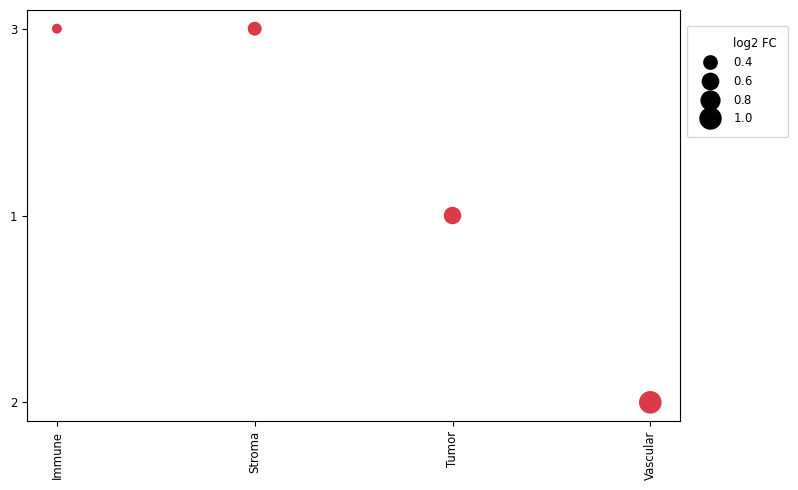

In [36]:
plot_enrichment(adata, group_key="niche", label_key="cell_type")